In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

base_dir = "/Users/jakobwerkgarner/code/mt_dsnow"
os.chdir(base_dir)

from HS2SWE.model.HS2SWE import HS2SWE
import HNW_validation.HNW_validation_helper as val_helper

In [2]:
# Load dataset
Mag25_data = xr.open_dataset("calibration/calibration_data/raw_data/Mag25/SLF_dataset/Mag25_all.nc")

# Create copy of original dataset
Mag25_data_with_SWE = Mag25_data.copy()

# Add empty SWE_mod variable for all stations
Mag25_data_with_SWE["SWE_mod"] = xr.full_like(Mag25_data_with_SWE["HS"], np.nan)

# Store number of observed SWE measurements per station
obs_counts = []

# Get all station names
station_list = Mag25_data["station"].values

for station_name in station_list:
    print(f"\nProcessing station: {station_name}")

    # Select one station
    idata = Mag25_data["HS"].transpose("time", "station").sel(station=station_name).to_pandas()

    # Convert to numpy and from m to cm
    idata_array = idata.to_numpy()
    idata_array_cm = idata_array * 100

    print(f"HS input shape: {idata_array_cm.shape}")

    # Reshape for HS2SWE
    idata_array_cm = idata_array_cm.reshape(-1, 1)

    # Run model
    hs2swe_results = HS2SWE(idata_array_cm)

    # Check shape
    assert hs2swe_results.shape == (Mag25_data.sizes["time"], 1)

    # Insert modeled values for this station
    Mag25_data_with_SWE["SWE_mod"].loc[dict(station=station_name)] = hs2swe_results[:, 0]

    # Count available observed SWE measurements
    swe_obs = Mag25_data_with_SWE["SWE"].sel(station=station_name)
    n_obs = swe_obs.notnull().sum().item()
    print(f"Number of SWE observations: {n_obs}")

    obs_counts.append({
        "station": station_name,
        "n_obs": n_obs
    })


# Create summary table
obs_counts_df = pd.DataFrame(obs_counts)
print(obs_counts_df)


Processing station: Adelboden
HS input shape: (2191,)
Running station: 1
Elapsed time for Station, 1 : 0.38598179817199707 s
Average time per station: 0.3862910270690918 s
Number of SWE observations: 32

Processing station: Gadmen
HS input shape: (2191,)
Running station: 1
Elapsed time for Station, 1 : 0.4836089611053467 s
Average time per station: 0.4839041233062744 s
Number of SWE observations: 0

Processing station: Grindelwald_Bort
HS input shape: (2191,)
Running station: 1
Elapsed time for Station, 1 : 0.5593416690826416 s
Average time per station: 0.5596771240234375 s
Number of SWE observations: 0

Processing station: Gsteig
HS input shape: (2191,)
Running station: 1
Elapsed time for Station, 1 : 0.5176241397857666 s
Average time per station: 0.5179111957550049 s
Number of SWE observations: 52

Processing station: Gantrisch
HS input shape: (2191,)
Running station: 1
Elapsed time for Station, 1 : 0.6038060188293457 s
Average time per station: 0.6041207313537598 s
Number of SWE ob

# Creat HNW_mod Data

In [3]:
# Calculate day-to-day SWE increase
HNW_mod = Mag25_data_with_SWE["SWE_mod"].diff(dim="time")

# Clip negative values to 0
HNW_mod = HNW_mod.clip(min=0)

# Reindex back to the original time axis
HNW_mod = HNW_mod.reindex(time=Mag25_data_with_SWE["time"])

# Add to dataset
Mag25_data_with_SWE["HNW_mod"] = HNW_mod

{'RMSE': np.float64(2.8963234302637573), 'Bias': np.float64(0.07145341503175535), 'Rel_BIAS': np.float64(0.03374520449738746), 'R2': np.float64(0.8403504785340428), 'N': 36487}
Plot saved to: HNW_validation/HS2SWE/validation_plots/deltasnow_hnw_validation_R_dyn_rho_max.png


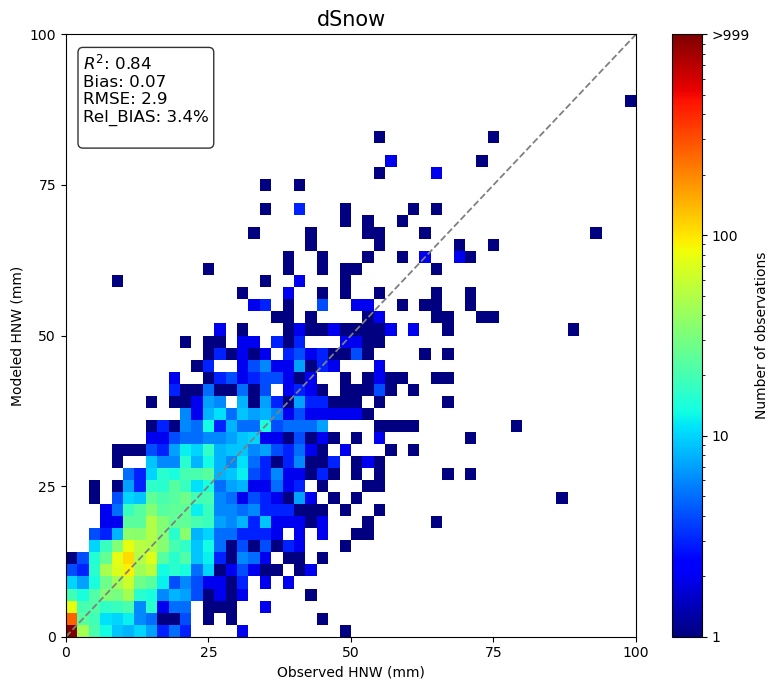

{'RMSE': np.float64(2.8963234302637573),
 'Bias': np.float64(0.07145341503175535),
 'Rel_BIAS': np.float64(0.03374520449738746),
 'R2': np.float64(0.8403504785340428),
 'N': 36487}

In [11]:
all_df = Mag25_data_with_SWE[["HNW", "HNW_mod"]].to_dataframe().reset_index()
all_df = all_df.rename(columns={
    "HNW": "HNW_obs",
    "HNW_mod": "HNW_mod"
})

all_df.index = all_df.index.astype("datetime64[ns]")

val_helper.validate_hnw_mag25(all_df,
                            model_name= 'dSnow', 
                            obs_col= "HNW_obs", 
                            mod_col= "HNW_mod",
                            save_dir="HNW_validation/HS2SWE/validation_plots",
                            filename="deltasnow_hnw_validation_R_dyn_rho_max.png")

In [ ]:
# Save output dataset
#Mag25_data_with_SWE.to_netcdf("HNW_validation/HS2SWE/validated_data/Mag25_HS2SWE_all_stations_final.nc")

# Validate SWE

Number of valid observations after filtering: 1102
{'RMSE': np.float64(32.80874188083544), 'Bias': np.float64(3.9449381186771606), 'Rel_BIAS': np.float64(0.01761103837796896), 'R2': np.float64(0.9585330975882308), 'N': 1102}
Plot saved to: HNW_validation/HS2SWE/validation_plots/deltasnow_SWE_validation_R_dyn_rho_max.png


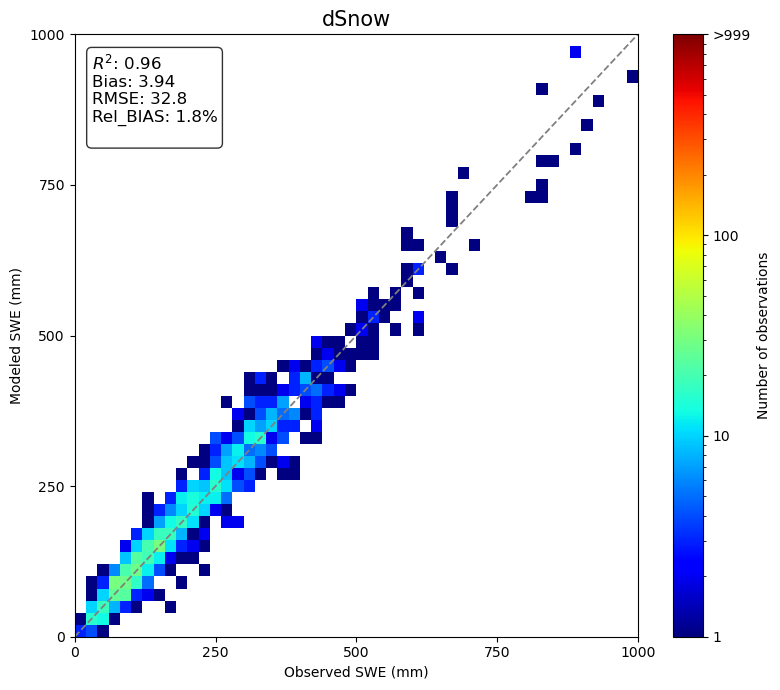

{'RMSE': np.float64(32.80874188083544),
 'Bias': np.float64(3.9449381186771606),
 'Rel_BIAS': np.float64(0.01761103837796896),
 'R2': np.float64(0.9585330975882308),
 'N': 1102}

In [10]:
all_df_SWE = Mag25_data_with_SWE[["SWE", "SWE_mod"]].to_dataframe().reset_index()
all_df_SWE = all_df_SWE.rename(columns={
    "SWE": "SWE_obs",
    "SWE_mod": "SWE_mod"
})

all_df_SWE.index = all_df_SWE.index.astype("datetime64[ns]")

val_helper.validate_swe_mag25(all_df_SWE, 
                              model_name="dSnow",
                              save_dir="HNW_validation/HS2SWE/validation_plots",
                              filename="deltasnow_SWE_validation_R_dyn_rho_max.png")